## Importing Data Files

In [2]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

c:\Users\EthanYongYuHeng\Desktop\F1-pitstop-prediction\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Download latest version
path = kagglehub.competition_download('playground-series-s6e5')

print("Path to competition files:", path)

Path to competition files: C:\Users\EthanYongYuHeng\.cache\kagglehub\competitions\playground-series-s6e5


In [4]:

train = pd.read_csv(f"{path}/train.csv")
test = pd.read_csv(f"{path}/test.csv")

print(train.head())

   id Driver Compound                   Race  Year  PitStop  LapNumber  Stint  \
0   0   D109     HARD    Canadian Grand Prix  2022        0         50      2   
1   1   D086     HARD       Dutch Grand Prix  2025        1         27      2   
2   2    ZON     HARD    Austrian Grand Prix  2022        0         59      3   
3   3    SPE   MEDIUM     Pre-Season Testing  2023        0          2      1   
4   4   D019     HARD  Azerbaijan Grand Prix  2022        1         26      3   

   TyreLife  Position  LapTime (s)  LapTime_Delta  Cumulative_Degradation  \
0      39.0         8       78.491         -7.564                  21.019   
1       7.0         4       75.095        -32.617                -223.207   
2      22.0        13       70.945         -7.540                -100.529   
3       2.0         7       94.361         -7.324                  -7.324   
4       6.0         2      107.878          8.965                 -14.139   

   RaceProgress  Position_Change  PitNextLap  
0  

In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  str    
 2   Compound                439140 non-null  str    
 3   Race                    439140 non-null  str    
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            439140 non-null  float64
 14  Position_Change         439140 

## Variable Categories
| Column                   | Type                             | Why                                  |
| ------------------------ | -------------------------------- | ------------------------------------ |
| `id`                     | Identifier                       | Unique row ID, not useful as feature |
| `Driver`                 | Categorical (nominal)            | Driver names/codes                   |
| `Compound`               | Categorical (nominal)            | HARD / MEDIUM / SOFT etc.            |
| `Race`                   | Categorical (nominal)            | Race/event name                      |
| `Year`                   | Numerical (discrete)             | Ordered integer year                 |
| `PitStop`                | Binary categorical               | 0 or 1                               |
| `LapNumber`              | Numerical (discrete ordinal)     | Ordered lap progression              |
| `Stint`                  | Ordinal categorical              | Ordered tyre stint number            |
| `TyreLife`               | Numerical (discrete)             | Tyre age in laps                     |
| `Position`               | Ordinal numerical                | Race ranking position                |
| `LapTime (s)`            | Numerical (continuous)           | Continuous time value                |
| `LapTime_Delta`          | Numerical (continuous)           | Difference in lap performance        |
| `Cumulative_Degradation` | Numerical (continuous)           | Engineered degradation metric        |
| `RaceProgress`           | Numerical (continuous)           | Normalized race percentage           |
| `Position_Change`        | Numerical (discrete signed)      | Gain/loss of positions               |
| `PitNextLap`             | Binary categorical (target-like) | Future pit indicator                 |


In [6]:
train.describe()

,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,219569.500000,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,126768.942943,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,0.000000,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,109784.750000,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,219569.500000,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,329354.250000,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000
max,439139.000000,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000


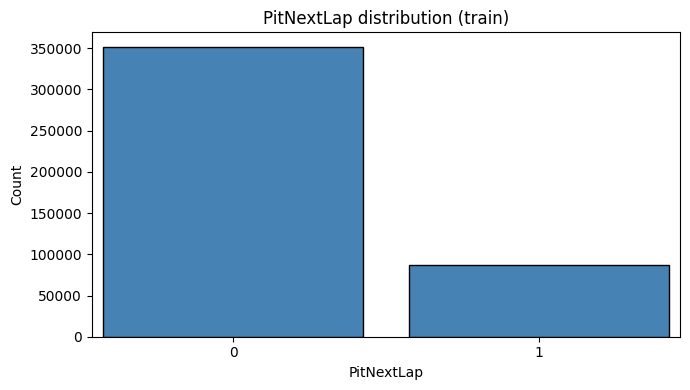

PitNextLap
0.0    0.801018
1.0    0.198982
Name: proportion, dtype: float64


In [7]:


fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(
    train["PitNextLap"],
    bins=np.arange(-0.5, 2, 1),
    edgecolor="black",
    rwidth=0.85,
    color="steelblue",
)
ax.set_xticks([0, 1])
ax.set_xlabel("PitNextLap")
ax.set_ylabel("Count")
ax.set_title("PitNextLap distribution (train)")
ax.margins(x=0.02)
plt.tight_layout()
plt.show()

print(train["PitNextLap"].value_counts(normalize=True).sort_index().rename("proportion"))